In [1]:
from pathlib import Path
from dotenv import load_dotenv
import os
import pandas as pd

ROOT = Path.cwd().parent

env_path = ROOT / ".env.backtest"

load_dotenv(env_path)

print(env_path)
print(os.getenv("MONGO_HOST"))

os.chdir(Path.cwd().parent)

/Users/paulvogt/mongo_db_streamlit/.env.backtest
localhost


In [2]:
%pwd

'/Users/paulvogt/mongo_db_streamlit'

In [3]:
from infrastructure.mongo.mongo_repository import MongoRepository
from config.mongo_config import MongoCollection, MongoDatabase, MongoUser
from infrastructure.mongo.mongo_connection import MongoConnection
from core.application.notebook_service import NotebookService

In [4]:
import pandas as pd
from config.pipeline_config import CONSTITUES

with MongoConnection(user=MongoUser.APPUSER) as conn:
    constituents_repo = MongoRepository(
        conn,
        MongoDatabase.PROCESSED,
        MongoCollection.SCD_CONSTITUENTS
    )
    raw_cons = MongoRepository(
        conn,
        MongoDatabase.RAW,
        MongoCollection.CONSTITUENTS
    )
    scd_df = pd.DataFrame(
        list(
            constituents_repo.find(
                projection={"symbol": 1, "fromDate": 1, "toDate": 1, "_id": 0}
            )
        )
    )

    raw_cons.execute_pipeline(CONSTITUES)
    raw_cons.create_index(keys=[("removedTicker", 1), ("date", 1)], unique=False)

    con_df = pd.DataFrame(
        list(
            raw_cons.find(sort={"date": 1})
        )
    )

In [5]:
con_df.head()

,_id,dateAdded,addedSecurity,removedTicker,removedSecurity,date,symbol,reason
0,69c650428de5ed10f4027048,"March 04, 1957",Curtiss Wright Corp,,,1957-03-03,CW,
1,69c650428de5ed10f4027051,"March 04, 1957",Dayton Power & Light Co,,,1957-03-03,DPL,
2,69c650428de5ed10f4027050,"March 04, 1957",Dow Chemical Company,,,1957-03-03,DOW,
3,69c650428de5ed10f402704f,"March 04, 1957",Dan River Inc,,,1957-03-03,DML,
4,69c650428de5ed10f402704e,"March 04, 1957",Dome Mines Ltd,,,1957-03-03,DM,


In [6]:
tick_added = con_df[["symbol", "addedSecurity"]].drop_duplicates()
tick_added.loc[tick_added["symbol"] == "", "symbol"] = None
tick_added.loc[tick_added["addedSecurity"] == "", "addedSecurity"] = None
tick_added = tick_added.dropna(how="all").reset_index(drop=True)
tick_added.head(5)

,symbol,addedSecurity
0,CW,Curtiss Wright Corp
1,DPL,Dayton Power & Light Co
2,DOW,Dow Chemical Company
3,DML,Dan River Inc
4,DM,Dome Mines Ltd


In [7]:
tick_removed = con_df[["removedTicker", "removedSecurity"]].drop_duplicates()
tick_removed.loc[tick_removed["removedTicker"] == "", "removedTicker"] = None
tick_removed.loc[tick_removed["removedSecurity"] == "", "removedSecurity"] = None
tick_removed = tick_removed.dropna(how="all").reset_index(drop=True).rename(columns={"removedTicker" : "symbol"})
tick_removed.head(5)

,symbol,removedSecurity
0,GN,Great Northern Railway Co
1,NP,Northern Pacific Railway Co
2,PUL,Publicker Industries Inc
3,ABW,Associated Brewing Co
4,BGT,Budget Industries Inc


In [8]:
df_merged = pd.merge(tick_added, tick_removed, how='outer', on="symbol" )
df_merged.head()

,symbol,addedSecurity,removedSecurity
0,A,Agilent Technologies Inc.,Anaconda Co
1,AA,NaN,Alcoa Inc
2,AAF,NaN,American Air Filter Inc
3,AAL,American Airlines Group,Alexander & Alexander Services Inc
4,AAL,American Airlines Group,American Airlines Group


AAL 
```{
        "dateAdded": "March 04, 1957",
        "addedSecurity": "American Airlines Group",
        "removedTicker": "",
        "removedSecurity": "",
        "date": "1957-03-03",
        "symbol": "AAL",
        "reason": ""
    },
{
        "dateAdded": "October 6, 1988",
        "addedSecurity": "Alexander & Alexander Services Inc",
        "removedTicker": "GLD",
        "removedSecurity": "Gould Inc",
        "date": "1988-10-06",
        "symbol": "AAL",
        "reason": "Annual Re-ranking"
    },
{
        "dateAdded": "January 14, 1997",
        "addedSecurity": "CNO Financial Group",
        "removedTicker": "AAL",
        "removedSecurity": "Alexander & Alexander Services Inc",
        "date": "1997-01-14",
        "symbol": "CNO",
        "reason": "Annual Re-ranking"
    },
{
        "dateAdded": "March 20, 2015",
        "addedSecurity": "American Airlines Group Inc",
        "removedTicker": "AGN",
        "removedSecurity": "Allergan Inc.",
        "date": "2015-03-20",
        "symbol": "AAL",
        "reason": "Allergan acquired by Actavis (and changed name to Allergan)."
    },
{
        "dateAdded": "September 23, 2024",
        "addedSecurity": "Palantir Technologies",
        "removedTicker": "AAL",
        "removedSecurity": "American Airlines Group",
        "date": "2024-09-23",
        "symbol": "PLTR",
        "reason": "Market capitalization change."
    }

AAL wird 3 mal eingefügt und nur 2 mal rausgenommen.

In [9]:
df_1957 = con_df[["symbol", "addedSecurity", "date"]]
df_1957 = df_1957.loc[df_1957["date"] == "1957-03-03"]
df_1957.describe()

,date
count,151
mean,1957-03-03 00:00:00
min,1957-03-03 00:00:00
25%,1957-03-03 00:00:00
50%,1957-03-03 00:00:00
75%,1957-03-03 00:00:00
max,1957-03-03 00:00:00


In [10]:
df_only_added = con_df
df_only_added = df_only_added.loc[df_only_added["removedTicker"] == ""].reset_index(drop=True)
df_only_added.tail(50)

,_id,dateAdded,addedSecurity,removedTicker,removedSecurity,date,symbol,reason
204,69c650428de5ed10f402700a,"March 04, 1957",Public Service Enterprise Group,,,1957-03-04,PEG,
205,69c650428de5ed10f4026fe3,"June 30, 1964",Sherwin-Williams,,,1964-06-30,SHW,
206,69c650428de5ed10f4026fe2,"March 31, 1965",Cummins,,,1965-03-31,CMI,
207,69c650428de5ed10f4026fe1,"March 31, 1965",Emerson Electric,,,1965-03-31,EMR,
208,69c650428de5ed10f4026fe0,"March 31, 1969",Clorox,,,1969-03-31,CLX,
209,69c650428de5ed10f4026fdf,"June 30, 1969",Newmont,,,1969-06-30,NEM,
210,69c650428de5ed10f4026e5e,"December 10, 1987",Fleming Companies,,,1987-12-10,FLM,Annual Re-ranking
211,69c650428de5ed10f4026d4a,"January 3, 2000",NCR Corp.,,,2000-01-03,NCR,Annual Re-ranking
212,69c650428de5ed10f4026d37,"June 16, 2000",Charter One Financial Inc,,,2000-06-16,CF,Annual Re-ranking
213,69c650428de5ed10f4026d1b,"December 4, 2000",Robert Half Int'l Inc,,,2000-12-04,RHI,Annual Re-ranking


In [11]:
df_only_removed = con_df
df_only_removed = df_only_removed.loc[df_only_removed["addedSecurity"] == ""].reset_index(drop=True)
df_only_removed.tail(50)

,_id,dateAdded,addedSecurity,removedTicker,removedSecurity,date,symbol,reason
27,69c650428de5ed10f4026d02,"August 2, 2001",,OAT,Quaker Oats Co,2001-08-02,PMCS,Annual Re-ranking
28,69c650428de5ed10f4026cfb,"September 17, 2001",,TOS,Tosco Corp.,2001-09-17,TOS,Annual Re-ranking
29,69c650428de5ed10f4026cf4,"December 12, 2001",,RAL,Ralston Purina Co.,2001-12-12,RAL,Annual Re-ranking
30,69c650428de5ed10f4026cdc,"August 30, 2002",,COC-B,Conoco Inc.,2002-08-30,COC-B,Annual Re-ranking
31,69c650428de5ed10f4026cc2,"November 30, 2004",,WLP,Wellpoint Health Networks Inc,2004-11-30,LLL,Annual Re-ranking
32,69c650428de5ed10f4026cc0,"December 17, 2004",,CR,Crane Co.,2004-12-17,ASN,Annual Re-ranking
33,69c650428de5ed10f4026cbf,"December 17, 2004",,DLX,Deluxe Corp.,2004-12-17,FOXA,Annual Re-ranking
34,69c650428de5ed10f4026cb1,"September 30, 2005",,G,Gillette Co.,2005-09-30,G,Annual Re-ranking
35,69c650428de5ed10f4026ca9,"January 3, 2006",,MERQ,Mercury Interactive Corp,2006-01-03,MERQ,Annual Re-ranking
36,69c650428de5ed10f4026c73,"September 24, 2007",,FDC,First Data Corp.,2007-09-24,FDC,FDC acquired by KKR.


LLL

```{
        "dateAdded": "June 28, 2019",
        "addedSecurity": "MarketAxess Holdings Inc",
        "removedTicker": "LLL",
        "removedSecurity": "L3 Technologies Inc",
        "date": "2019-06-28",
        "symbol": "MKTX",
        "reason": "L3 purchased by Harris Corporation"
    },
    {
        "dateAdded": "November 30, 2004",
        "addedSecurity": "",
        "removedTicker": "WLP",
        "removedSecurity": "Wellpoint Health Networks Inc",
        "date": "2004-11-30",
        "symbol": "LLL",
        "reason": "Annual Re-ranking"
    },

    IN MEINER COMPANY DATA:
    {
  "_id": {
    "$oid": "69ac0300fdf7b4ac98cc7a02"
  },
  "symbol": "LLL",
  "companyName": "JX Luxventure Limited",
  "image": "https://images.financialmodelingprep.com/symbol/LLL.png",
  "sector": "Consumer Cyclical"
}
````
LLL wird hinzugefügt aber ohne addedSecurity. Dann wird es removed aber mit "removedSecurity": "L3 Technologies Inc". Der eigentliche Name in der CompanyData Datei ist "companyName": "JX Luxventure Limited" mit dem "ipoDate": "2013-03-07",

# SCD - TEST


In [12]:
scd_df.head()

,symbol,fromDate,toDate
0,AYE,1900-01-01,1976-07-01 00:00:00
1,HNG,1900-01-01,1976-07-01 00:00:00
2,MCK,1900-01-01,1994-09-30 00:00:00
3,USL,1900-01-01,1997-06-17 00:00:00
4,SUN,1900-01-01,1998-12-11 00:00:00


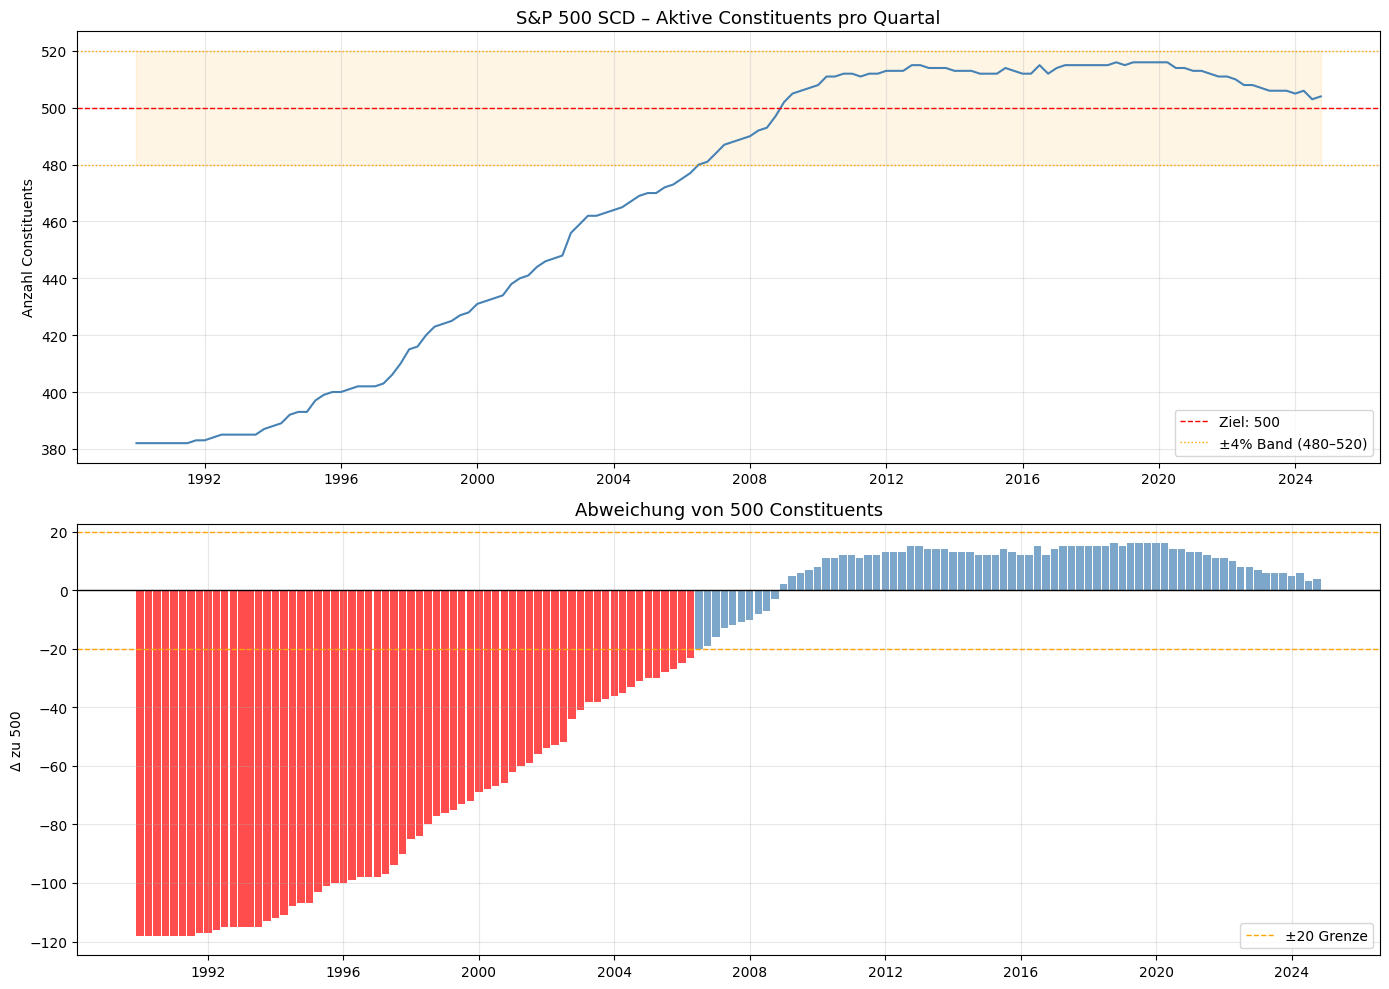

SCD VALIDIERUNG – ZUSAMMENFASSUNG
Zeitraum:          1990-01-01 – 2024-10-01
Ø Constituents:    466.8
Median:            488
Min:               382 (1990-01-01)
Max:               516 (2018-10-01)
Std:               49.9

Innerhalb ±10:     14.3% der Zeitpunkte  ⚠️
Innerhalb ±20:     52.9% der Zeitpunkte  ⚠️

⚠️  66 Quartale außerhalb ±20:
      date  count  deviation
1990-01-01    382       -118
1990-04-01    382       -118
1990-07-01    382       -118
1990-10-01    382       -118
1991-01-01    382       -118
1991-04-01    382       -118
1991-07-01    382       -118
1991-10-01    383       -117
1992-01-01    383       -117
1992-04-01    384       -116
1992-07-01    385       -115
1992-10-01    385       -115
1993-01-01    385       -115
1993-04-01    385       -115
1993-07-01    385       -115
1993-10-01    387       -113
1994-01-01    388       -112
1994-04-01    389       -111
1994-07-01    392       -108
1994-10-01    393       -107
1995-01-01    393       -107
1995-04-01    397   

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Generate date range to check
date_range = pd.date_range(start='1990-01-01', end='2024-12-31', freq='QS')

# Count active constituents per date
counts = []
for date in date_range:
    active = ((scd_df['fromDate'] <= date) & (scd_df['toDate'] >= date)).sum()
    counts.append({'date': date, 'count': active})

count_df = pd.DataFrame(counts)
count_df['deviation'] = count_df['count'] - 500

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1) Time series of constituent count
ax1 = axes[0]
ax1.plot(count_df['date'], count_df['count'], linewidth=1.5, color='steelblue')
ax1.axhline(500, color='red', linestyle='--', linewidth=1, label='Ziel: 500')
ax1.axhline(480, color='orange', linestyle=':', linewidth=1, label='±4% Band (480–520)')
ax1.axhline(520, color='orange', linestyle=':', linewidth=1)
ax1.fill_between(count_df['date'], 480, 520, alpha=0.1, color='orange')
ax1.set_title('S&P 500 SCD – Aktive Constituents pro Quartal', fontsize=13)
ax1.set_ylabel('Anzahl Constituents')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 2) Deviation from 500
ax2 = axes[1]
colors = ['red' if abs(d) > 20 else 'steelblue' for d in count_df['deviation']]
ax2.bar(count_df['date'], count_df['deviation'], width=80, color=colors, alpha=0.7)
ax2.axhline(0, color='black', linewidth=1)
ax2.axhline(20, color='orange', linestyle='--', linewidth=1, label='±20 Grenze')
ax2.axhline(-20, color='orange', linestyle='--', linewidth=1)
ax2.set_title('Abweichung von 500 Constituents', fontsize=13)
ax2.set_ylabel('Δ zu 500')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

# --- Summary Stats ---
print("=" * 50)
print("SCD VALIDIERUNG – ZUSAMMENFASSUNG")
print("=" * 50)
print(f"Zeitraum:          {count_df['date'].min().date()} – {count_df['date'].max().date()}")
print(f"Ø Constituents:    {count_df['count'].mean():.1f}")
print(f"Median:            {count_df['count'].median():.0f}")
print(f"Min:               {count_df['count'].min()} ({count_df.loc[count_df['count'].idxmin(), 'date'].date()})")
print(f"Max:               {count_df['count'].max()} ({count_df.loc[count_df['count'].idxmax(), 'date'].date()})")
print(f"Std:               {count_df['count'].std():.1f}")
print()

pct_ok   = (count_df['count'].between(490, 510)).mean() * 100
pct_warn = (count_df['count'].between(480, 520)).mean() * 100
print(f"Innerhalb ±10:     {pct_ok:.1f}% der Zeitpunkte  {'✅' if pct_ok  > 80 else '⚠️'}")
print(f"Innerhalb ±20:     {pct_warn:.1f}% der Zeitpunkte  {'✅' if pct_warn > 80 else '⚠️'}")
print()

# Problematic periods
outliers = count_df[~count_df['count'].between(480, 520)]
if len(outliers) > 0:
    print(f"⚠️  {len(outliers)} Quartale außerhalb ±20:")
    print(outliers[['date', 'count', 'deviation']].to_string(index=False))
else:
    print("✅ Keine Ausreißer außerhalb ±20")